# Image Restoration Using Wiener and Richardson-Lucy Deconvolution
Image degradation due to blurring and noise is a common issue in image processing. Various restoration techniques attempt to recover lost details while minimizing artifacts. This notebook explores two well-known deblurring techniques: Wiener Filtering and Richardson-Lucy Deconvolution.

In [10]:
import cv2
import numpy as np
from skimage import restoration, img_as_float
import matplotlib.pyplot as plt

## 1. The Wiener Filter
### 1.1 Blur Simulation
Before applying Wiener Filter, we simulate image degradation by convolving the original image with a low-pass filter, which primarily introduces defocusing blur, a common type of degradation in optical systems.

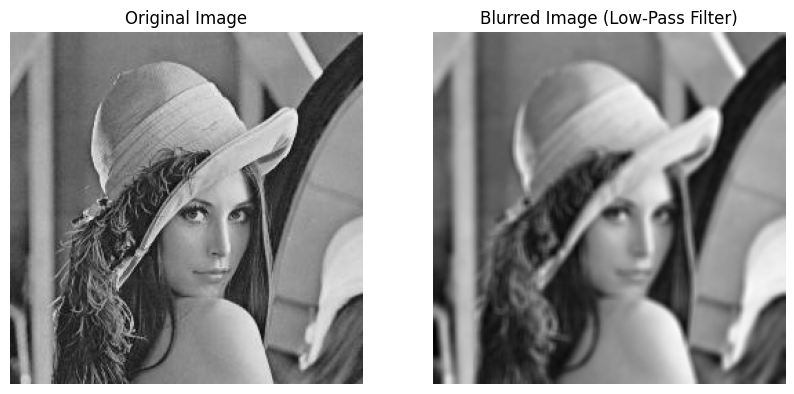

In [3]:
# Read the grayscale image
img1 = cv2.imread("data/lena.jpg", cv2.IMREAD_GRAYSCALE)

# Define a 5x5 low-pass filter (averaging filter)
kernel_size = 5
lowpass_filter = np.ones((kernel_size, kernel_size), np.float32)  # Create a kernel filled with ones
lowpass_filter /= np.sum(lowpass_filter)  # Normalize the filter to maintain brightness

# Apply the low-pass filter using convolution
img_conv = cv2.filter2D(img1, -1, lowpass_filter)

# Display the original and blurred images
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_conv, cmap='gray')
axes[1].set_title('Blurred Image (Low-Pass Filter)')
axes[1].axis('off')

plt.show()

Increasing the kernel size results in stronger blurring, leading to greater information loss.

### 1.2 Image Restoration Using the Wiener Filter

The **Wiener filter** is a deblurring technique based on **inverse filtering** with added regularization to handle noise. It works in the **frequency domain** and aims to recover the original image by compensating for the degradation caused by blurring while minimizing noise amplification.  

Mathematically, the Wiener filter is defined as:  

$$
W(f) = \frac{H^*(f)}{|H(f)|^2 + k}
$$

where:  
- $ H(f) $ is the Fourier transform of the blur kernel (Point Spread Function, PSF).  
- $ H^*(f) $ is its complex conjugate.  
- $ k $ is a **regularization parameter** that controls the balance between deblurring and noise suppression.  

The restored image in the frequency domain is obtained by:  

$$
F_{\text{rec}}(f) = W(f) F_{\text{blurred}}(f)
$$

Applying the **inverse Fourier transform** gives the final restored image:  

$$
\text{Restored Image} = \mathcal{F}^{-1}(F_{\text{rec}})
$$

In [4]:
def wiener_filter(img_blurred, lowpass_filter, k=0.01):
    """
    Apply the Wiener filter to restore a blurred image.
    
    Parameters:
    - img_blurred: np.ndarray, the blurred input image.
    - lowpass_filter: np.ndarray, the known point spread function (PSF).
    - k: float, regularization parameter to handle noise (default: 0.01).
    
    Returns:
    - img_restored: np.ndarray, the restored image.
    """
    shape = img_blurred.shape  # Get image dimensions

    # Compute the Fourier Transform of the blurred image
    F_blurred = np.fft.fft2(img_blurred, s=shape)

    # Compute the Fourier Transform of the PSF (low-pass filter)
    H = np.fft.fft2(lowpass_filter, s=shape)

    # Compute the Wiener filter
    wiener_filter = np.conj(H) / (np.abs(H) ** 2 + k)

    # Apply the filter in the frequency domain
    F_restored = wiener_filter * F_blurred

    # Compute the inverse Fourier Transform to get the restored image
    img_restored = np.fft.ifft2(F_restored).real

    # Normalize and convert to uint8
    img_restored = np.clip(img_restored, 0, 255).astype(np.uint8)

    return img_restored

We compute the Wiener filte with different regularization parameters (k values: 0.001, 0.01, 0.1, 1):

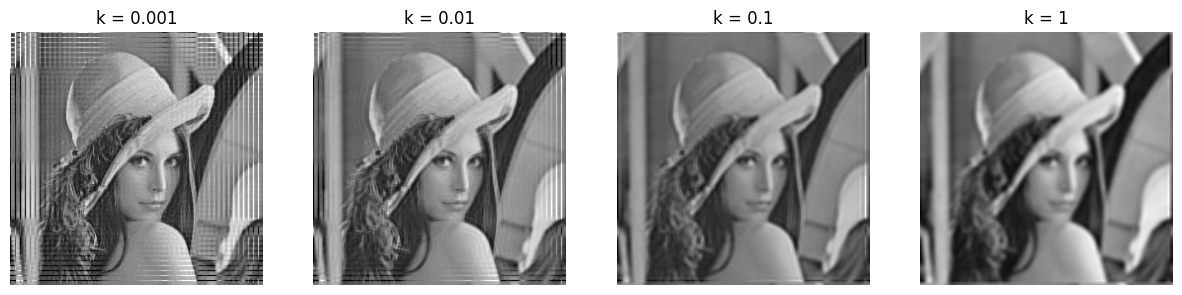

In [5]:
k_values = [0.001, 0.01, 0.1, 1]  # Different regularization parameters
restored_images = []

for k in k_values:
    # Apply Wiener filter with different k values
    img_rec = wiener_filter(img_conv, lowpass_filter, k)
    restored_images.append(img_rec)

# Display results
fig, axes = plt.subplots(1, len(k_values), figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(restored_images[i], cmap='gray')
    ax.set_title(f'k = {k_values[i]}')
    ax.axis('off')

plt.show()

- **Low k values (0.001, 0.01):** Strong deblurring but noise amplification.
- **Higher k values (0.1, 1):** More noise suppression, but residual blur remains.
- **Best k value:** Typically 0.01 provides the best balance.

In general, The **optimal k** depends on the noise level in the image.

Now, we apply the Wiener filter to restore the image:

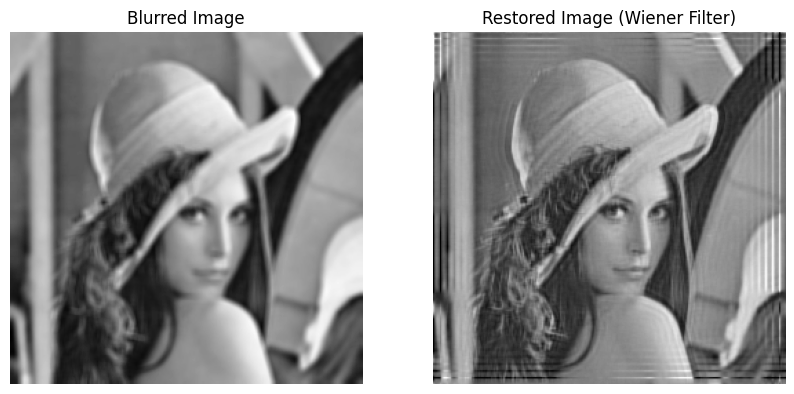

In [6]:
# Apply Wiener filter
img_rec = wiener_filter(img_conv, lowpass_filter, k=0.01)

# Display the results
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(img_conv, cmap='gray')
axes[0].set_title('Blurred Image')
axes[0].axis('off')

axes[1].imshow(img_rec, cmap='gray')
axes[1].set_title('Restored Image (Wiener Filter)')
axes[1].axis('off')

plt.show()

- The Wiener filter effectively reduces the blur and recovers important image structures.
- The edges appear significantly enhanced compared to the blurred image, demonstrating the filter’s ability to counteract defocus blur.
- Ringing artifacts are introduced, especially around edges, due to the amplification of high-frequency components during restoration.

## 2. Richardson-Lucy Deconvolution

Richardson-Lucy deconvolution is an iterative algorithm that estimates the original image using a likelihood-based approach. It is particularly effective when the blur kernel is well-defined.

### 2.1 Motion Blur Simulation
To evaluate the effectiveness of the Richardson-Lucy deconvolution, we first apply motion blur to the original image. Motion blur occurs when an object moves during image capture, leading to a directional blur effect. We simulate this using convolution with a motion blur kernel.

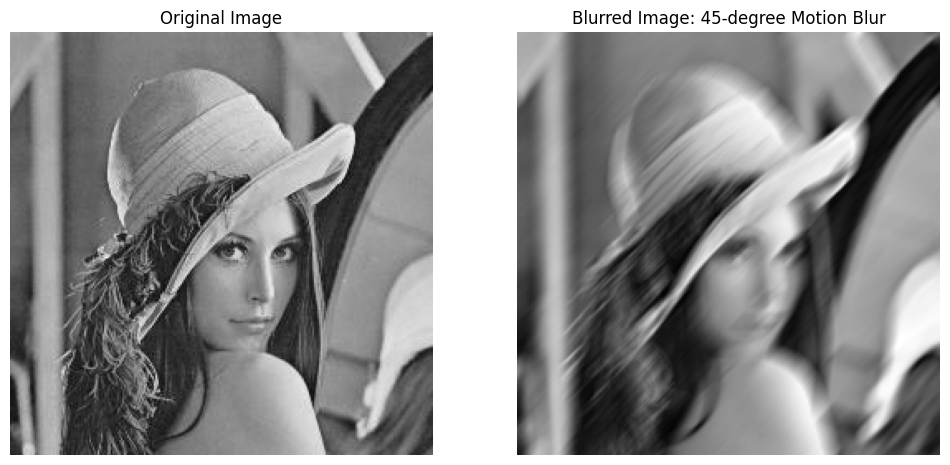

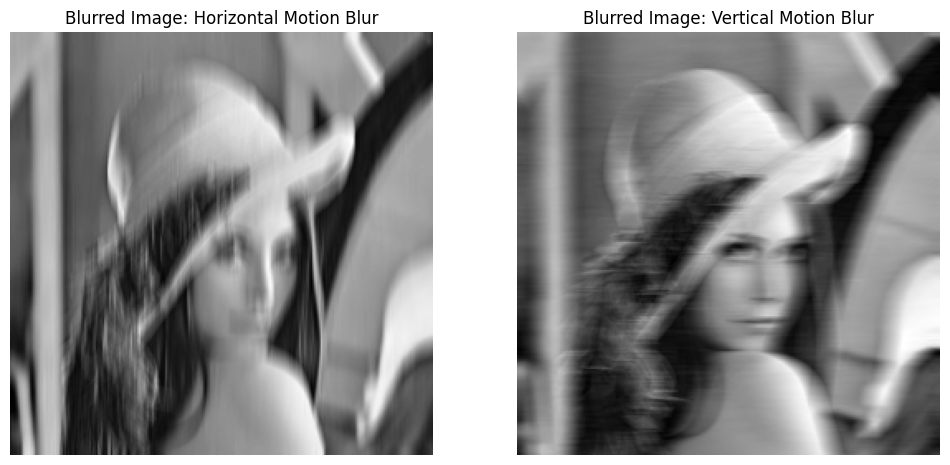

In [8]:
# Define the kernel size for motion blur
kernel_size = 15  

# Lists to store blurred images and corresponding kernels
blurred_imgs = []
kernels = []

# Define motion blur directions: (1,1) for diagonal, (1,0) for horizontal, (0,1) for vertical
kernel_directions = [(1, 1), (1, 0), (0, 1)]  

# Generate motion blur kernels and apply them to the image
for direction in kernel_directions:
    # Initialize a kernel filled with zeros
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)

    # Set the center row to ones to create a basic horizontal motion blur kernel
    kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size, dtype=np.float32)

    # Rotate the kernel to match the desired blur direction
    rotation_angle = np.arctan2(*direction) * 180 / np.pi  # Convert direction to an angle
    kernel = cv2.warpAffine(kernel, cv2.getRotationMatrix2D((kernel_size / 2 - 0.5, kernel_size / 2 - 0.5), 
                                                             rotation_angle, 1.0), 
                            (kernel_size, kernel_size))

    # Normalize the kernel so that the sum of all elements is 1
    kernel = kernel / np.sum(kernel)  

    # Apply the motion blur to the original image
    blurred_img = cv2.filter2D(img1, -1, kernel)

    # Store the kernel and blurred image for later visualization
    kernels.append(kernel)
    blurred_imgs.append(blurred_img)

# Display the original and blurred images

# First figure: Original image and 45-degree motion blur
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
axes1[0].imshow(img1, cmap='gray')
axes1[0].set_title('Original Image')
axes1[0].axis('off')

axes1[1].imshow(blurred_imgs[0], cmap='gray')
axes1[1].set_title('Blurred Image: 45-degree Motion Blur')
axes1[1].axis('off')

# Second figure: Horizontal and vertical motion blur comparisons
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
axes2[0].imshow(blurred_imgs[1], cmap='gray')
axes2[0].set_title('Blurred Image: Horizontal Motion Blur')
axes2[0].axis('off')

axes2[1].imshow(blurred_imgs[2], cmap='gray')
axes2[1].set_title('Blurred Image: Vertical Motion Blur')
axes2[1].axis('off')

plt.show()

### 2.2 Richardson-Lucy Deconvolution for Restoration
The Richardson-Lucy (RL) deconvolution is an iterative algorithm used to restore a blurred image by estimating the most likely original image. It is based on **Bayesian probability** and **Poisson statistics**, making it particularly useful for images degraded by motion blur or diffraction effects.

The RL algorithm iteratively refines an estimate of the original image \(I\) using the following update rule:

$$
I^{(t+1)} = I^{(t)} \cdot \left( \frac{I_{\text{blurred}} \circledast K^*}{I^{(t)} \circledast K} \right)
$$

where:

- $ I^{(t)} $ is the estimated image at iteration $ t $.
- $ I_{\text{blurred}} $ is the observed blurred image.
- $ K $ is the blur kernel (point spread function).
- $ K^* $ is the flipped kernel used for deconvolution.
- $ \circledast $ represents convolution.

The algorithm iteratively improves the estimate $ I^{(t)} $, reducing the impact of the blur kernel while preserving image details.

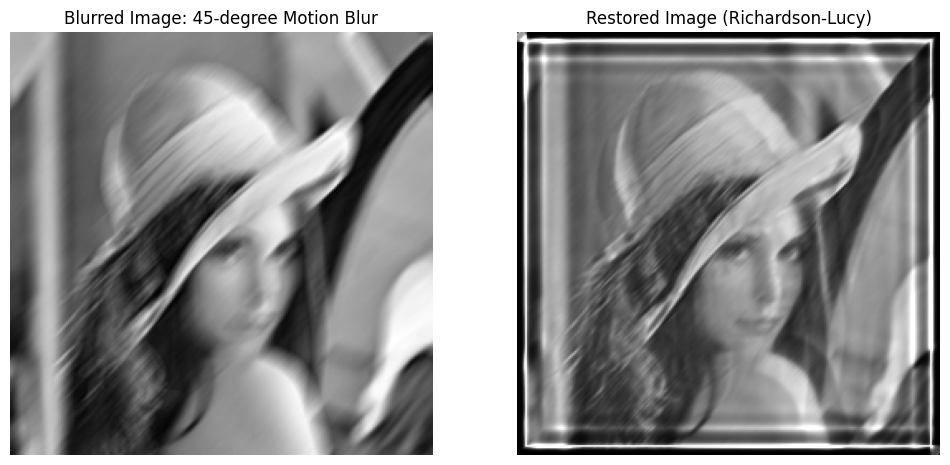

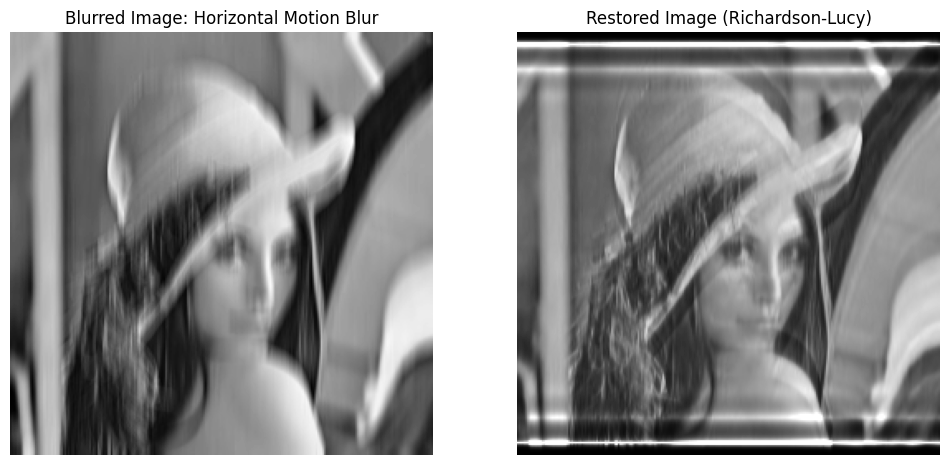

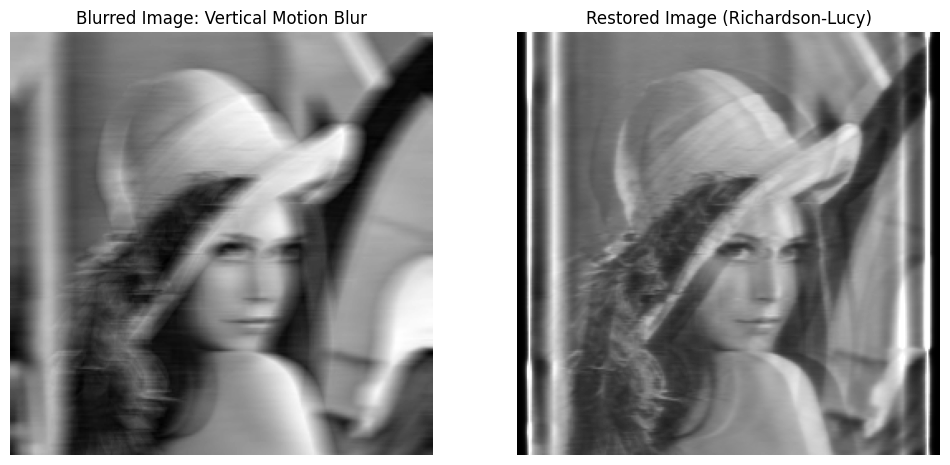

In [9]:
# List to store restored images
restored_imgs = []

# Set the number of iterations for the Richardson-Lucy deconvolution algorithm
num_iterations = 20  
    
# Iterate over the blurred images to apply Richardson-Lucy deconvolution
for i in range(len(blurred_imgs)):
    # Convert the blurred image to float format (required for deconvolution)
    img_float = img_as_float(blurred_imgs[i])
    
    # Apply the Richardson-Lucy deconvolution algorithm using the corresponding blur kernel
    img_deconvolved = restoration.richardson_lucy(img_float, kernels[i], num_iter=num_iterations)
    
    # Store the restored image
    restored_imgs.append(img_deconvolved)

# Display the blurred and restored images for different motion blur directions

# First figure: 45-degree motion blur and its restoration
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
axes1[0].imshow(blurred_imgs[0], cmap='gray')
axes1[0].set_title('Blurred Image: 45-degree Motion Blur')
axes1[0].axis('off')

axes1[1].imshow(restored_imgs[0], cmap='gray')
axes1[1].set_title('Restored Image (Richardson-Lucy)')
axes1[1].axis('off')

# Second figure: Horizontal motion blur and its restoration
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
axes2[0].imshow(blurred_imgs[1], cmap='gray')
axes2[0].set_title('Blurred Image: Horizontal Motion Blur')
axes2[0].axis('off')

axes2[1].imshow(restored_imgs[1], cmap='gray')
axes2[1].set_title('Restored Image (Richardson-Lucy)')
axes2[1].axis('off')

# Third figure: Vertical motion blur and its restoration
fig3, axes3 = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
axes3[0].imshow(blurred_imgs[2], cmap='gray')
axes3[0].set_title('Blurred Image: Vertical Motion Blur')
axes3[0].axis('off')

axes3[1].imshow(restored_imgs[2], cmap='gray')
axes3[1].set_title('Restored Image (Richardson-Lucy)')
axes3[1].axis('off')

# Show all figures
plt.show()

- The image progressively sharpens over iterations, restoring finer details more effectively.
- Increasing the number of iterations improves sharpness but may introduce noise.
- The performance depends on how accurately the blur kernel approximates the real degradation process.